In [1]:
import os
import random
import numpy as np
import tensorflow as tf

def set_global_determinism(seed=42):

    random.seed(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)

    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)
    tf.config.experimental.enable_op_determinism()



In [2]:
!pip install tensorflow-model-optimization tf-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 61.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires 

In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, MaxPooling1D, Input, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


In [3]:
import pandas as pd
import numpy as np
import os
import glob
import random
import re
from sklearn.preprocessing import StandardScaler
import joblib

DATA_PATH = ''

WINDOW_SIZE = 80
STEP_SIZE = 40
FEATURES = ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2']
LABEL_MAP = {
    '1_Nod': 0,
    '2_Head_Shake': 1,
    '3_Tilt_Left': 2,
    '4_Tilt_Right': 3,
    '5_Look_up': 4,
    '6_Look_down': 5,
    '7_Idle': 6
}

In [4]:
def get_label_from_string(label_str):
    """Helper to extract the 0-6 integer label from a string like '1_Nod'"""
    match = re.search(r'\d', str(label_str))
    if match:
        return int(match.group()) - 1
    return None

def create_windows(df, window_size, step_size):
    windows, labels = [], []
    for i in range(0, len(df) - window_size, step_size):
        window = df[FEATURES].iloc[i : i + window_size].values
        label = get_label_from_string(df['activity'].iloc[i])

        if label is not None and window.shape == (window_size, 12):
            windows.append(window)
            labels.append(label)
    return np.array(windows), np.array(labels)

def get_windows_from_file_list(file_list):
    x_list, y_list = [], []
    for f in file_list:
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()
        x_w, y_w = create_windows(df, window_size=WINDOW_SIZE, step_size=STEP_SIZE)
        if len(x_w) > 0:
            x_list.append(x_w)
            y_list.append(y_w)

    if not x_list:
        return np.array([]), np.array([])
    return np.concatenate(x_list), np.concatenate(y_list)


all_csvs = [f for f in glob.glob(os.path.join(DATA_PATH, "*.csv")) if 'test' not in f.lower()]
print(f"Total Clean Files Found: {len(all_csvs)}")

activity_buckets = {i: [] for i in range(7)}

for f in all_csvs:
    try:
        df_head = pd.read_csv(f, nrows=1)
        label = get_label_from_string(df_head['activity'].iloc[0])
        if label is not None and label in activity_buckets:
            activity_buckets[label].append(f)
    except Exception as e:
        print(f"Error reading {f}: {e}")

train_files_list, val_files_list, test_files_list = [], [], []

random.seed(42)
for label, files_in_bucket in activity_buckets.items():
    random.shuffle(files_in_bucket)
    total_in_bucket = len(files_in_bucket)

    val_count = max(1, int(total_in_bucket * 0.15)) # Ensure at least 1 file if bucket is small
    test_count = max(1, int(total_in_bucket * 0.15))

    val_files_list.extend(files_in_bucket[:val_count])
    test_files_list.extend(files_in_bucket[val_count : val_count + test_count])
    train_files_list.extend(files_in_bucket[val_count + test_count:])
print(f"Files for Training: {len(train_files_list)}")
print(f"Files for Validation: {len(val_files_list)}")
print(f"Files for Testing: {len(test_files_list)}\n")

X_train_raw, y_train = get_windows_from_file_list(train_files_list)
X_val_raw, y_val = get_windows_from_file_list(val_files_list)
X_test_raw, y_test = get_windows_from_file_list(test_files_list)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw.reshape(-1, 12))

X_val_scaled = scaler.transform(X_val_raw.reshape(-1, 12))
X_test_scaled = scaler.transform(X_test_raw.reshape(-1, 12))

X_train = X_train_scaled.reshape(-1, WINDOW_SIZE, 12)
X_val = X_val_scaled.reshape(-1, WINDOW_SIZE, 12)
X_test = X_test_scaled.reshape(-1, WINDOW_SIZE, 12)

joblib.dump(scaler, 'gesture_scaler.pkl')

print("Data Scaled Successfully!\n")
print(f"Final Training Shape:   {X_train.shape}, Labels: {y_train.shape}")
print(f"Final Validation Shape: {X_val.shape}, Labels: {y_val.shape}")
print(f"Final Test Shape:       {X_test.shape}, Labels: {y_test.shape}")

Total Clean Files Found: 28
Files for Training: 14
Files for Validation: 7
Files for Testing: 7

Data Scaled Successfully!

Final Training Shape:   (1699, 80, 12), Labels: (1699,)
Final Validation Shape: (930, 80, 12), Labels: (930,)
Final Test Shape:       (874, 80, 12), Labels: (874,)



Window Distribution Across Classes
              Train  Validation  Test  Total
1_Nod           123         155   123    401
2_Head_Shake    242         151    81    474
3_Tilt_Left     277          93   152    522
4_Tilt_Right    278         101   122    501
5_Look_up       227         154   122    503
6_Look_down     275         121   150    546
7_Idle          277         155   124    556


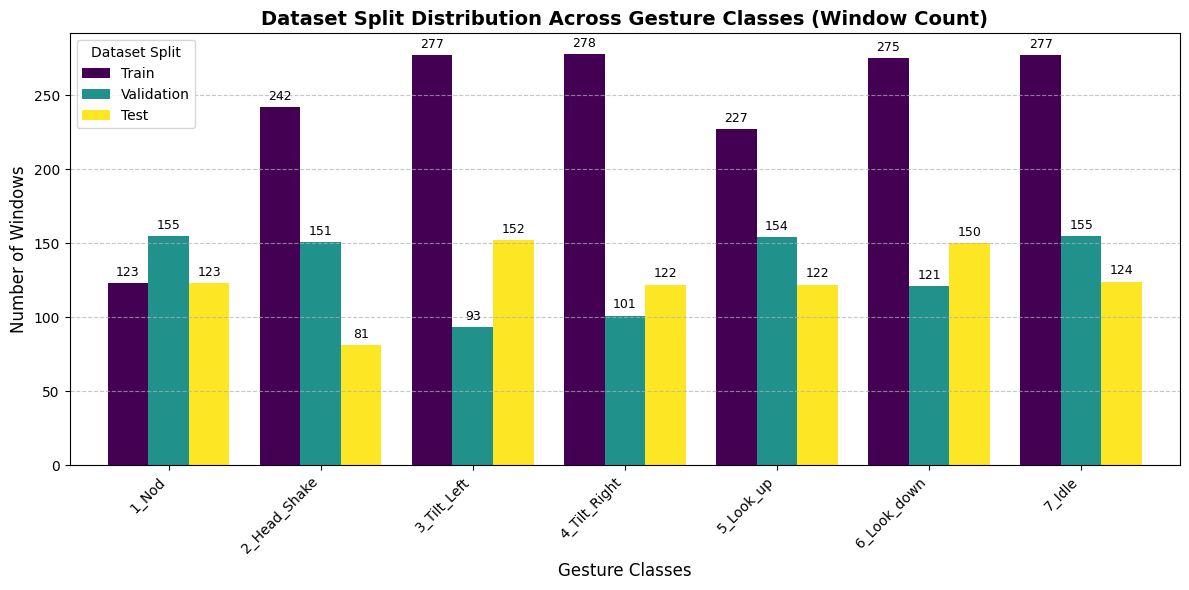

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

def get_class_counts(y_array, num_classes=7):
    if len(y_array) == 0:
        return np.zeros(num_classes, dtype=int)
    return np.bincount(y_array, minlength=num_classes)
train_counts = get_class_counts(y_train)
val_counts = get_class_counts(y_val)
test_counts = get_class_counts(y_test)

df_distribution = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
}, index=[REVERSE_LABEL_MAP[i] for i in range(7)])

df_distribution['Total'] = df_distribution['Train'] + df_distribution['Validation'] + df_distribution['Test']

print("\nWindow Distribution Across Classes")
print(df_distribution)

plot_data = df_distribution.drop(columns=['Total'])

ax = plot_data.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='viridis')

plt.title('Dataset Split Distribution Across Gesture Classes (Window Count)', fontsize=14, fontweight='bold')
plt.xlabel('Gesture Classes', fontsize=12)
plt.ylabel('Number of Windows', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dataset Split')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 3),
                    textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()

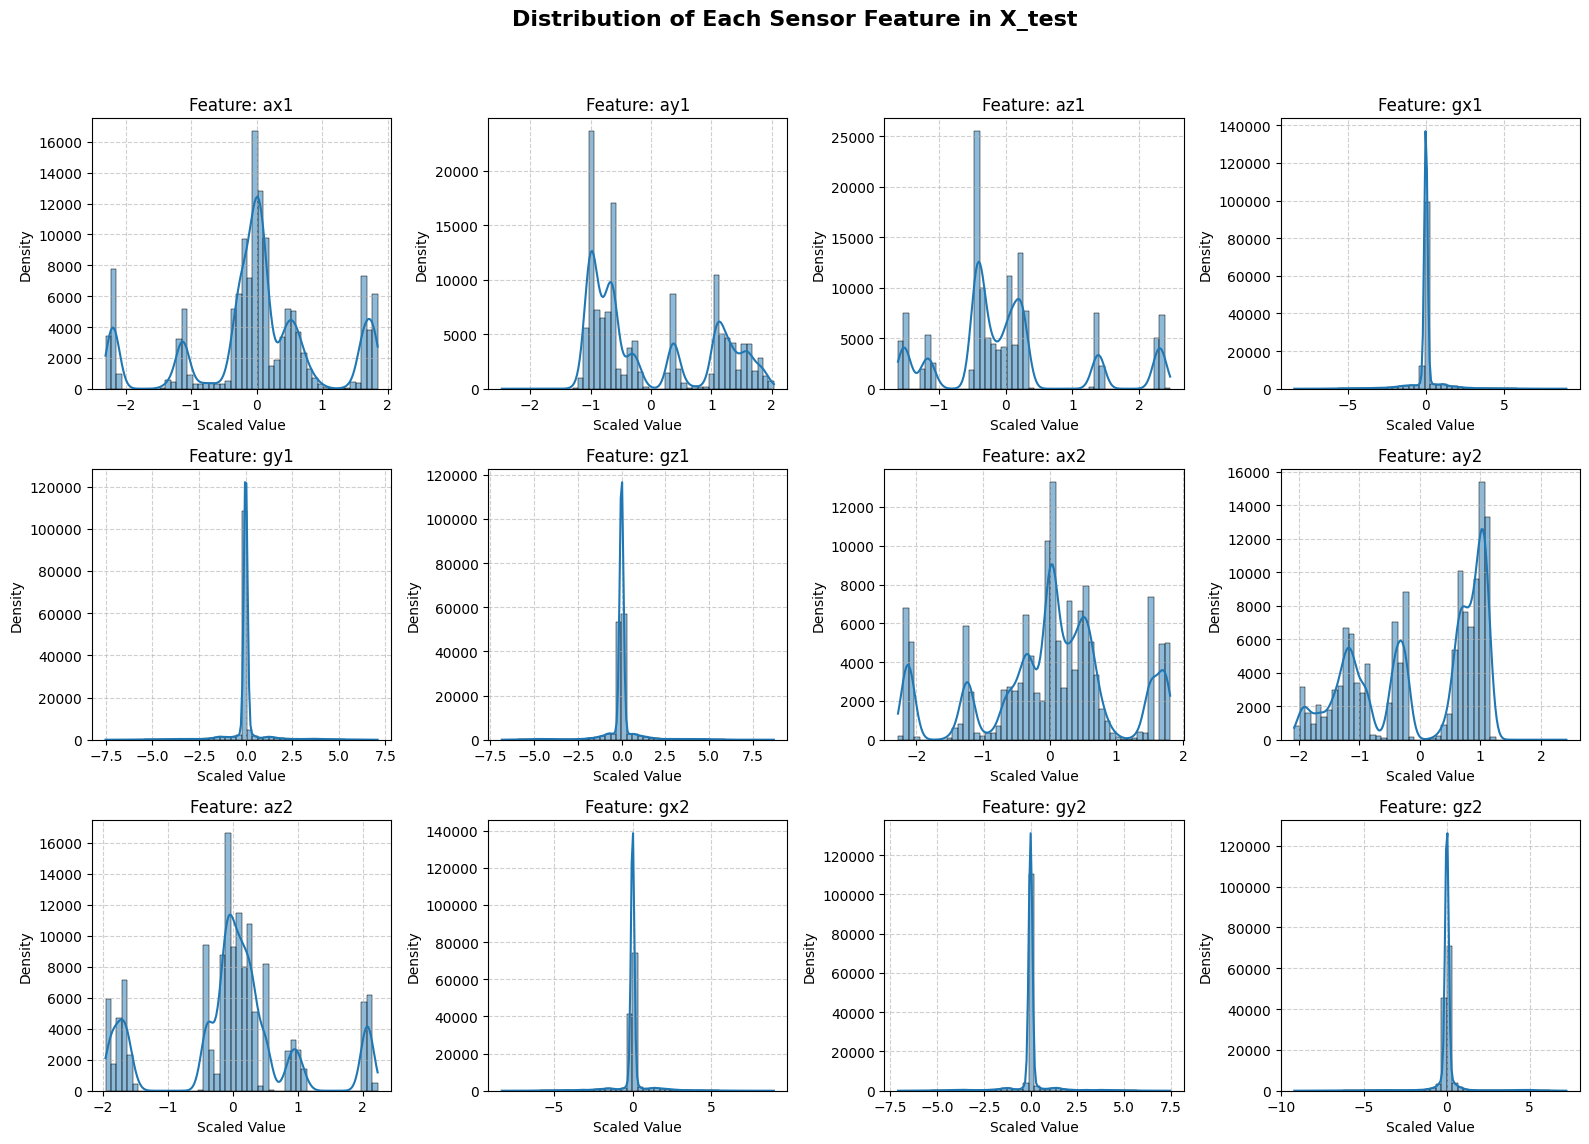

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
X_train_reshaped = X_train.reshape(-1, X_test.shape[2])

plt.figure(figsize=(16, 12))
plt.suptitle('Distribution of Each Sensor Feature in X_test', fontsize=16, fontweight='bold')

for i, feature_name in enumerate(FEATURES):
    plt.subplot(3, 4, i + 1)
    sns.histplot(X_train_reshaped[:, i], bins=50, kde=True)
    plt.title(f'Feature: {feature_name}')
    plt.xlabel('Scaled Value')
    plt.ylabel('Density')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [7]:
from sklearn.decomposition import PCA
import pandas as pd

X_train_reshaped_pca = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped_pca = X_test.reshape(X_test.shape[0], -1)

pca = PCA(n_components=2)
pca.fit(X_train_reshaped_pca)

X_train_pca = pca.transform(X_train_reshaped_pca)
X_test_pca = pca.transform(X_test_reshaped_pca)
df_train_pca = pd.DataFrame(data=X_train_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_train_pca['Gesture'] = [REVERSE_LABEL_MAP[label] for label in y_train]

df_test_pca = pd.DataFrame(data=X_test_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_test_pca['Gesture'] = [REVERSE_LABEL_MAP[label] for label in y_test]


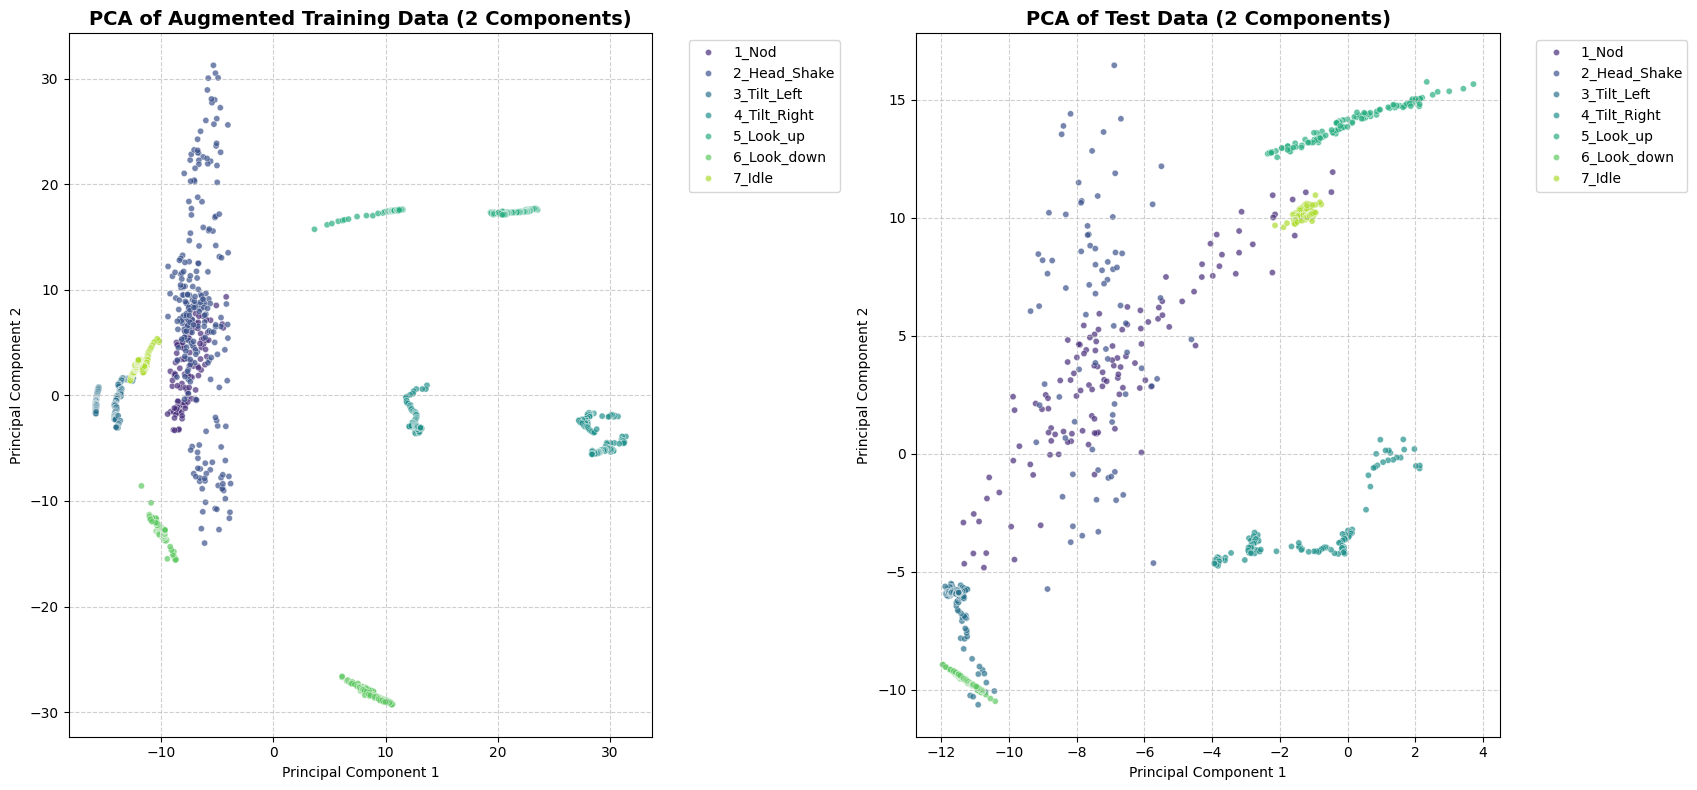

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x='Principal Component 1', y='Principal Component 2',
    hue='Gesture', data=df_train_pca,
    palette='viridis', alpha=0.7, s=20
)
plt.title('PCA of Augmented Training Data (2 Components)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
sns.scatterplot(
    x='Principal Component 1', y='Principal Component 2',
    hue='Gesture', data=df_test_pca,
    palette='viridis', alpha=0.7, s=20
)
plt.title('PCA of Test Data (2 Components)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

Class Weights applied to balance training:
Class 0: 1.973
Class 1: 1.003
Class 2: 0.876
Class 3: 0.873
Class 4: 1.069
Class 5: 0.883
Class 6: 0.876


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_1                │ (None, 80, 12)         │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 78, 32)         │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 78, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 76, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 76, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,703 (37.90 KB)

 Trainable params: 9,703 (37.90 KB)

 Non-trainable params: 0 (0.00 B)


Starting Training
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7816 - loss: 0.9680 - val_accuracy: 0.9882 - val_loss: 0.2298
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 1.0000 - loss: 0.0364 - val_accuracy: 0.9978 - val_loss: 0.0536
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 0.9978 - val_loss: 0.0330
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9978 - val_loss: 0.0240
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9978 - val_loss: 0.0216
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9978 - val_loss: 0.0185
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9989 - val_loss: 0.0162
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 7.1163

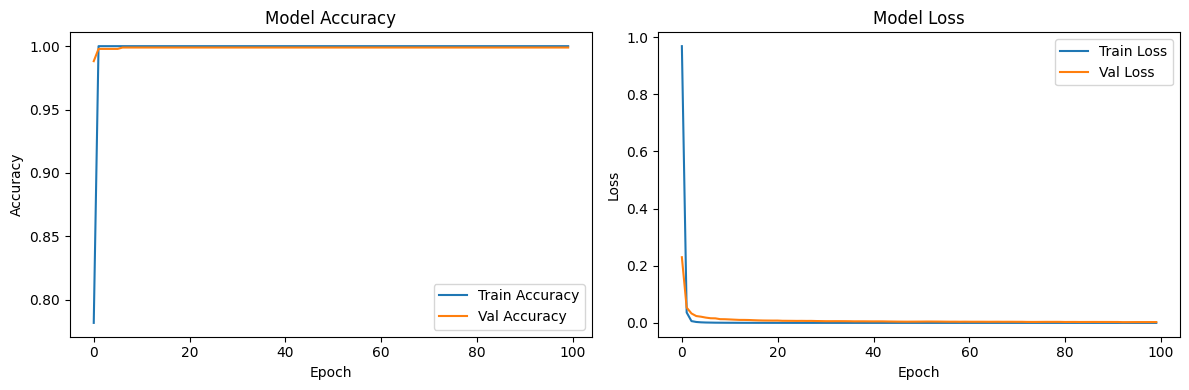


Evaluating on Test Set
Final Accuracy on Unseen Test Set: 96.45%

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


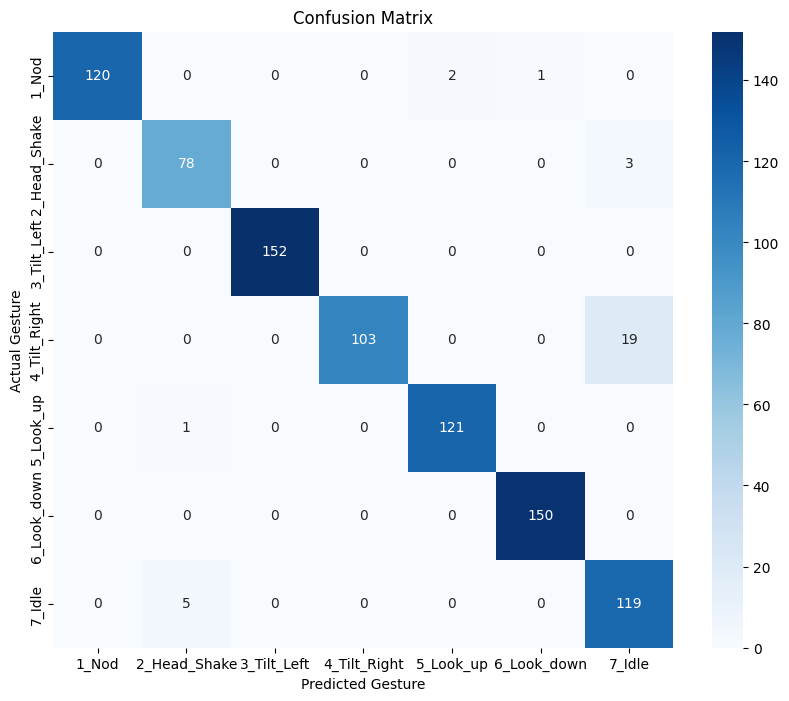


 Detailed Classification Report
              precision    recall  f1-score   support

       1_Nod       1.00      0.98      0.99       123
2_Head_Shake       0.93      0.96      0.95        81
 3_Tilt_Left       1.00      1.00      1.00       152
4_Tilt_Right       1.00      0.84      0.92       122
   5_Look_up       0.98      0.99      0.99       122
 6_Look_down       0.99      1.00      1.00       150
      7_Idle       0.84      0.96      0.90       124

    accuracy                           0.96       874
   macro avg       0.96      0.96      0.96       874
weighted avg       0.97      0.96      0.96       874


Sample of Test Results
   Actual Gesture Predicted Gesture  Match
0           1_Nod             1_Nod   True
1           1_Nod             1_Nod   True
2           1_Nod             1_Nod   True
3           1_Nod             1_Nod   True
4           1_Nod             1_Nod   True
5           1_Nod             1_Nod   True
6           1_Nod             1_Nod   True
7 

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, GlobalAveragePooling1D, GaussianNoise, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Class Weights applied to balance training:")
for c, w in class_weight_dict.items():
    print(f"Class {c}: {w:.3f}")

model = Sequential([
    Input(shape=(80, 12)),
    GaussianNoise(0.1),

    Conv1D(filters=32, kernel_size=3, activation='relu'),
    Dropout(0.4),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Dropout(0.4),

    GlobalAveragePooling1D(),
    Dense(32, activation='relu'),
    Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nStarting Training")
history = model.fit(
    X_train, to_categorical(y_train, 7),
    epochs=100,
    batch_size=32,
    validation_data=(X_val, to_categorical(y_val, 7)),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

print("\nEvaluating on Test Set")
test_loss, test_accuracy = model.evaluate(X_test, to_categorical(y_test, 7), verbose=0)
print(f"Final Accuracy on Unseen Test Set: {test_accuracy * 100:.2f}%\n")
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
label_names = [REVERSE_LABEL_MAP[i] for i in range(7)]

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Gesture')
plt.xlabel('Predicted Gesture')
plt.show()

print("\n Detailed Classification Report")
print(classification_report(y_test, y_pred_classes, target_names=label_names, zero_division=0))
actual_names = [REVERSE_LABEL_MAP[i] for i in y_test]
predicted_names = [REVERSE_LABEL_MAP[i] for i in y_pred_classes]

results_df = pd.DataFrame({
    'Actual Gesture': actual_names,
    'Predicted Gesture': predicted_names,
    'Match': [a == p for a, p in zip(actual_names, predicted_names)]
})

print("\nSample of Test Results")
print(results_df.head(15))

In [12]:
import time
test_loss, original_test_accuracy = model.evaluate(X_test, to_categorical(y_test, 7), verbose=0)
print(f"Final Accuracy on Unseen Test Set: {original_test_accuracy * 100:.2f}%\n")

model.save('original_model.keras')
original_model_size_kb = os.path.getsize('original_model.keras') / 1024
print(f"Original Model File Size: {original_model_size_kb:.2f} KB")

#Inference Time
start_time = time.time()
y_pred_probs = model.predict(X_test, verbose=0)
end_time = time.time()

original_inference_time_ms = ((end_time - start_time) / len(X_test)) * 1000
print(f"Original Keras Inference Time (per sample): {original_inference_time_ms:.4f} ms")

Final Accuracy on Unseen Test Set: 96.45%

Original Model File Size: 152.26 KB
Original Keras Inference Time (per sample): 0.1942 ms


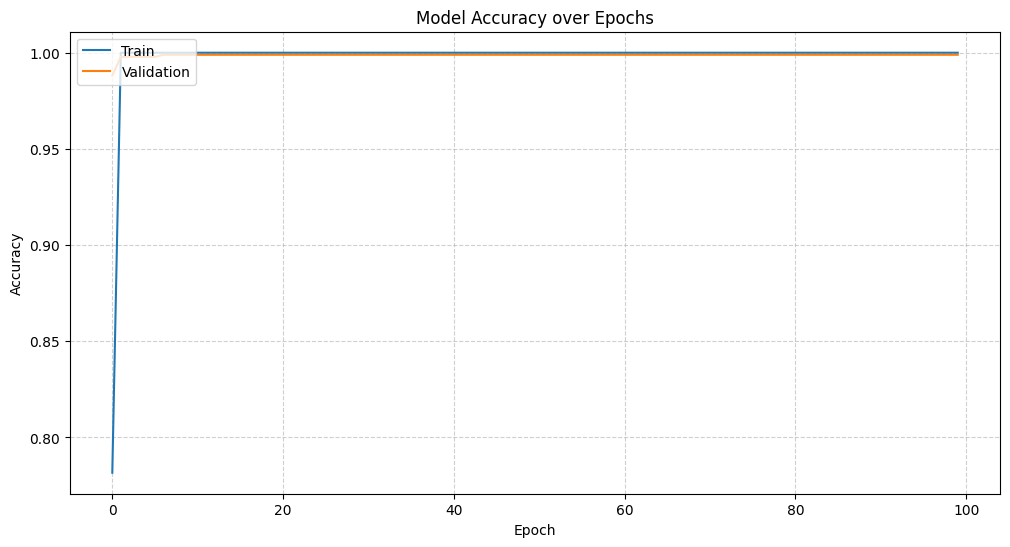

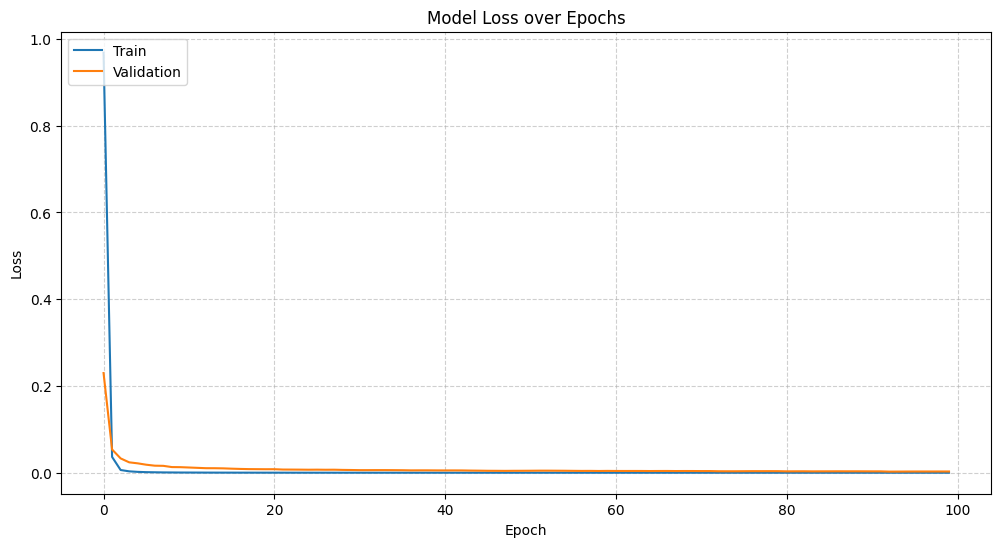

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [13]:
model_filename = 'base_gesture_model.h5'
model.save(model_filename)
print(f"\nBase Model saved successfully as: {model_filename}")


Base Model saved successfully as: base_gesture_model.h5


In [31]:
!pip install tf_keras


In [32]:
import tensorflow_model_optimization as tfmot
import time
import os

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

batch_size = 32
epochs = 20

num_samples = int(X_train.shape[0] * 0.9)
end_step = np.ceil(num_samples / batch_size).astype(np.int32) * epochs

pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.50,
        final_sparsity=0.80,
        begin_step=0,
        end_step=end_step
    )
}

import tf_keras

pruning_model = tf_keras.Sequential([
    tf_keras.layers.Input(shape=(80, 12)),
    tf_keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    tf_keras.layers.Dropout(0.4),
    tf_keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    tf_keras.layers.Dropout(0.4),
    tf_keras.layers.GlobalAveragePooling1D(),
    tf_keras.layers.Dense(32, activation='relu'),
    tf_keras.layers.Dense(7, activation='softmax')
])

pruning_model.set_weights(model.get_weights())
pruning_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



_, baseline_acc = pruning_model.evaluate(X_test, to_categorical(y_test, 7), verbose=0)

_, baseline_acc = pruning_model.evaluate(X_test, to_categorical(y_test, 7), verbose=0)
print(f"Baseline Accuracy (before pruning): {baseline_acc * 100:.2f}%")

model_for_pruning = prune_low_magnitude(pruning_model, **pruning_params)
model_for_pruning.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]

print("\nFine-tuning pruned model...")
model_for_pruning.fit(
    X_train, to_categorical(y_train, 7),
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, to_categorical(y_val, 7)),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

model_for_export = tfmot.sparsity.keras.strip_pruning(model_for_pruning)
model_for_export.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

_, pruned_accuracy = model_for_export.evaluate(X_test, to_categorical(y_test, 7), verbose=0)
print(f"\nPruned Model Accuracy: {pruned_accuracy * 100:.2f}%")

print("\nConverting to Int8 TFLite...")

def representative_dataset():
    np.random.seed(42)
    indices = np.random.choice(len(X_train), size=500, replace=False)
    for i in indices:
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter._experimental_disable_per_channel_quantization_for_dense_layers = True

tflite_model = converter.convert()

tflite_filename = 'har_cnn_quantized.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

tflite_model_size_kb = os.path.getsize(tflite_filename) / 1024
print(f"Quantized TFLite Model Size: {tflite_model_size_kb:.2f} KB")

interpreter = tf.lite.Interpreter(model_path=tflite_filename)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

scale, zero_point = input_details[0]['quantization']

print("\nRunning Inference on TFLite model...")
start_time = time.time()
correct_predictions = 0

for i in range(len(X_test)):
    input_data = np.expand_dims(X_test[i], axis=0).astype(np.float32)
    input_data = np.round(input_data / scale + zero_point).astype(np.int8)
    input_data = np.clip(input_data, -128, 127).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_label = np.argmax(output_data)

    if predicted_label == y_test[i]:
        correct_predictions += 1

end_time = time.time()

tflite_inference_time_ms = ((end_time - start_time) / len(X_test)) * 1000
tflite_test_accuracy = correct_predictions / len(X_test)

print(f"\nQuantized TFLite Accuracy: {tflite_test_accuracy * 100:.2f}%")
print(f"Quantized TFLite Inference Time (per sample): {tflite_inference_time_ms:.4f} ms")

print(f"\nTFLITE_SCALE      = {scale}")
print(f"TFLITE_ZERO_POINT = {zero_point}")


Baseline Accuracy (before pruning): 96.45%

Fine-tuning pruned model...
Epoch 1/20
54/54 [==============================] - 11s 56ms/step - loss: 1.8600e-06 - accuracy: 1.0000 - val_loss: 0.0014 - val_accuracy: 1.0000
Epoch 2/20
54/54 [==============================] - 2s 29ms/step - loss: 3.2628e-04 - accuracy: 1.0000 - val_loss: 0.0328 - val_accuracy: 0.9989
Epoch 3/20
54/54 [==============================] - 1s 25ms/step - loss: 1.2909e-04 - accuracy: 1.0000 - val_loss: 0.0188 - val_accuracy: 0.9989
Epoch 4/20
54/54 [==============================] - 2s 29ms/step - loss: 2.3727e-04 - accuracy: 1.0000 - val_loss: 0.0135 - val_accuracy: 0.9978
Epoch 5/20
54/54 [==============================] - 2s 30ms/step - loss: 7.7444e-05 - accuracy: 1.0000 - val_loss: 0.0094 - val_accuracy: 0.9989
Epoch 6/20
54/54 [==============================] - 2s 42ms/step - loss: 1.6438e-04 - accuracy: 1.0000 - val_loss: 0.0149 - val_accuracy: 0.9978
Epoch 7/20
54/54 [==============================] - 2s 41

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized TFLite Model Size: 16.56 KB

Running Inference on TFLite model...

Quantized TFLite Accuracy: 85.24%
Quantized TFLite Inference Time (per sample): 0.0678 ms

TFLITE_SCALE      = 0.07092371582984924
TFLITE_ZERO_POINT = 0


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [35]:
interpreter = tf.lite.Interpreter(model_path='har_cnn_quantized.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
scale, zero_point = input_details[0]['quantization']

correct = 0
start_time = time.time()

for i in range(len(X_test)):
    input_data = np.expand_dims(X_test[i], axis=0).astype(np.float32)
    input_data = np.round(input_data / scale + zero_point).astype(np.int8)
    input_data = np.clip(input_data, -128, 127).astype(np.int8)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    if np.argmax(output_data) == y_test[i]:
        correct += 1

end_time = time.time()
ptq_time = ((end_time - start_time) / len(X_test)) * 1000

print(f"PTQ TFLite Accuracy: {correct / len(X_test) * 100:.2f}%")
print(f"PTQ Inference Time (per sample): {ptq_time:.4f} ms")
print(f"TFLITE_SCALE      = {scale}")
print(f"TFLITE_ZERO_POINT = {zero_point}")


PTQ TFLite Accuracy: 85.24%
PTQ Inference Time (per sample): 0.1079 ms
TFLITE_SCALE      = 0.07092371582984924
TFLITE_ZERO_POINT = 0


In [33]:
import tf_keras
import tensorflow_model_optimization as tfmot

qat_model = tf_keras.Sequential([
    tf_keras.layers.Reshape((80, 1, 12), input_shape=(80, 12)),
    tf_keras.layers.Conv2D(filters=32, kernel_size=(3, 1), activation='relu'),
    tf_keras.layers.Dropout(0.4),
    tf_keras.layers.Conv2D(filters=64, kernel_size=(3, 1), activation='relu'),
    tf_keras.layers.Dropout(0.4),
    tf_keras.layers.GlobalAveragePooling2D(),
    tf_keras.layers.Dense(32, activation='relu'),
    tf_keras.layers.Dense(7, activation='softmax')
])

qat_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

q_aware_model = tfmot.quantization.keras.quantize_model(qat_model)
q_aware_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = tf_keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Quantization-Aware Training")
q_aware_model.fit(
    X_train, tf_keras.utils.to_categorical(y_train, 7),
    epochs=100,
    batch_size=32,
    validation_data=(X_val, tf_keras.utils.to_categorical(y_val, 7)),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

_, qat_accuracy = q_aware_model.evaluate(X_test, tf_keras.utils.to_categorical(y_test, 7), verbose=0)
print(f"\nQAT Model Accuracy: {qat_accuracy * 100:.2f}%")

def representative_dataset():
    np.random.seed(42)
    indices = np.random.choice(len(X_train), size=500, replace=False)
    for i in indices:
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter._experimental_disable_per_channel_quantization_for_dense_layers = True

tflite_model = converter.convert()

with open('har_qat_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"QAT TFLite Model Size: {os.path.getsize('har_qat_model.tflite') / 1024:.2f} KB")

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
scale, zero_point = input_details[0]['quantization']

correct = 0
for i in range(len(X_test)):
    input_data = np.expand_dims(X_test[i], axis=0).astype(np.float32)
    input_data = np.round(input_data / scale + zero_point).astype(np.int8)
    input_data = np.clip(input_data, -128, 127).astype(np.int8)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    if np.argmax(output_data) == y_test[i]:
        correct += 1

print(f"Quantized TFLite Accuracy: {correct / len(X_test) * 100:.2f}%")
print(f"\nTFLITE_SCALE      = {scale}")
print(f"TFLITE_ZERO_POINT = {zero_point}")


Quantization-Aware Training
Epoch 1/100
54/54 [==============================] - 4s 21ms/step - loss: 1.0456 - accuracy: 0.6645 - val_loss: 0.4893 - val_accuracy: 0.8301
Epoch 2/100
54/54 [==============================] - 1s 14ms/step - loss: 0.0604 - accuracy: 1.0000 - val_loss: 0.2352 - val_accuracy: 0.8935
Epoch 3/100
54/54 [==============================] - 1s 15ms/step - loss: 0.0092 - accuracy: 1.0000 - val_loss: 0.1827 - val_accuracy: 0.9387
Epoch 4/100
54/54 [==============================] - 1s 15ms/step - loss: 0.0044 - accuracy: 1.0000 - val_loss: 0.1727 - val_accuracy: 0.9387
Epoch 5/100
54/54 [==============================] - 1s 15ms/step - loss: 0.0026 - accuracy: 1.0000 - val_loss: 0.1622 - val_accuracy: 0.9398
Epoch 6/100
54/54 [==============================] - 1s 14ms/step - loss: 0.0018 - accuracy: 1.0000 - val_loss: 0.1629 - val_accuracy: 0.9398
Epoch 7/100
54/54 [==============================] - 1s 15ms/step - loss: 0.0012 - accuracy: 1.0000 - val_loss: 0.1596 -

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [37]:
interpreter = tf.lite.Interpreter(model_path='har_qat_model.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
scale, zero_point = input_details[0]['quantization']

correct = 0
start_time = time.time()

for i in range(len(X_test)):
    input_data = np.expand_dims(X_test[i], axis=0).astype(np.float32)
    input_data = np.round(input_data / scale + zero_point).astype(np.int8)
    input_data = np.clip(input_data, -128, 127).astype(np.int8)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    if np.argmax(output_data) == y_test[i]:
        correct += 1

end_time = time.time()
qat_time = ((end_time - start_time) / len(X_test)) * 1000

print(f"QAT TFLite Accuracy: {correct / len(X_test) * 100:.2f}%")
print(f"QAT Inference Time (per sample): {qat_time:.4f} ms")
print(f"TFLITE_SCALE      = {scale}")
print(f"TFLITE_ZERO_POINT = {zero_point}")


QAT TFLite Accuracy: 84.10%
QAT Inference Time (per sample): 0.1095 ms
TFLITE_SCALE      = 0.07134705036878586
TFLITE_ZERO_POINT = 1


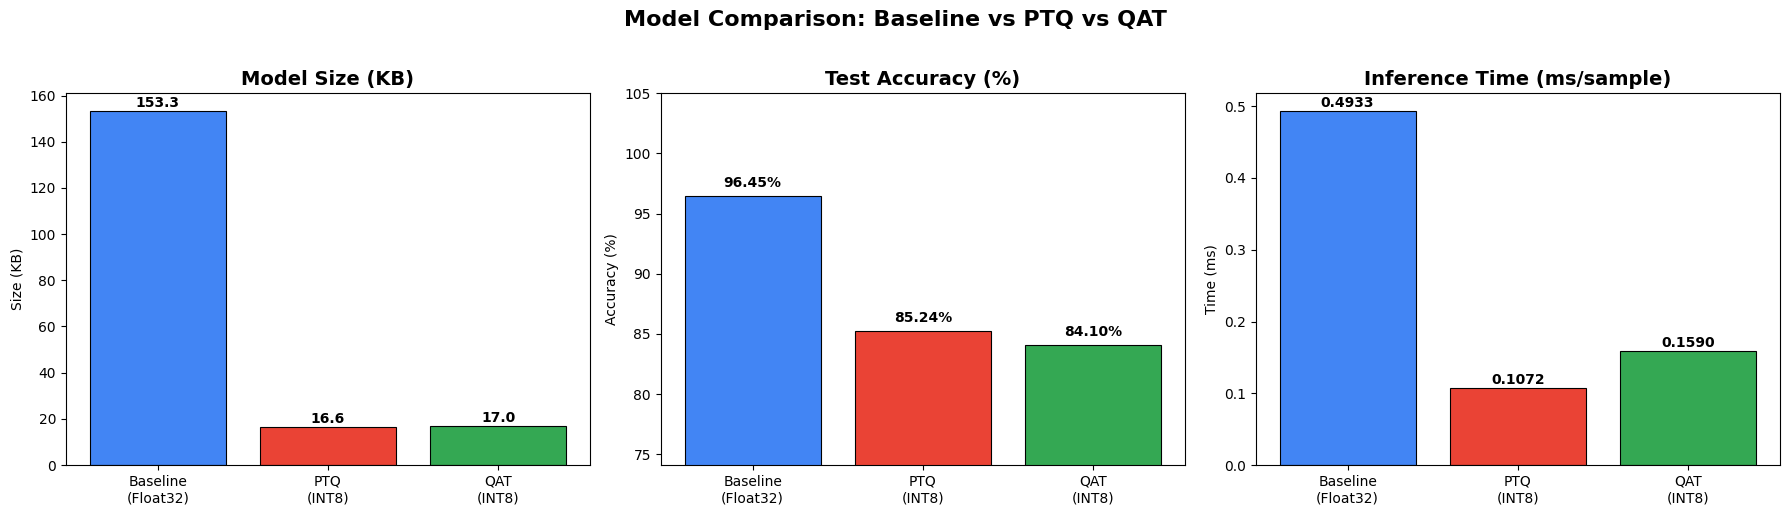

Model           Size (KB)    Accuracy     Inference (ms) 
------------------------------------------------------
Baseline        153.3        96.45        0.4933         
PTQ             16.6         85.24        0.1072         
QAT             17.0         84.10        0.1590         


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time

baseline_model_path = 'har_baseline.h5'
model.save(baseline_model_path)
baseline_size_kb = os.path.getsize(baseline_model_path) / 1024
ptq_size_kb = os.path.getsize('har_cnn_quantized.tflite') / 1024
qat_size_kb = os.path.getsize('har_qat_model.tflite') / 1024

_, baseline_accuracy = model.evaluate(X_test, to_categorical(y_test, 7), verbose=0)
baseline_accuracy *= 100

start_time = time.time()
model.predict(X_test, verbose=0)
end_time = time.time()
baseline_time = ((end_time - start_time) / len(X_test)) * 1000

def measure_tflite(model_path):
    interp = tf.lite.Interpreter(model_path=model_path)
    interp.allocate_tensors()
    inp = interp.get_input_details()
    out = interp.get_output_details()
    scale, zp = inp[0]['quantization']
    correct = 0
    start = time.time()
    for i in range(len(X_test)):
        data = np.expand_dims(X_test[i], axis=0).astype(np.float32)
        data = np.round(data / scale + zp).astype(np.int8)
        data = np.clip(data, -128, 127).astype(np.int8)
        interp.set_tensor(inp[0]['index'], data)
        interp.invoke()
        output = interp.get_tensor(out[0]['index'])
        if np.argmax(output) == y_test[i]:
            correct += 1
    end = time.time()
    acc = (correct / len(X_test)) * 100
    inf_time = ((end - start) / len(X_test)) * 1000
    return acc, inf_time

ptq_acc, ptq_time = measure_tflite('har_cnn_quantized.tflite')
qat_acc, qat_time = measure_tflite('har_qat_model.tflite')

labels = ['Baseline\n(Float32)', 'PTQ\n(INT8)', 'QAT\n(INT8)']
sizes = [baseline_size_kb, ptq_size_kb, qat_size_kb]
accuracies = [baseline_accuracy, ptq_acc, qat_acc]
times = [baseline_time, ptq_time, qat_time]
colors = ['#4285F4', '#EA4335', '#34A853']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars1 = axes[0].bar(labels, sizes, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Model Size (KB)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Size (KB)')
for bar, val in zip(bars1, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

bars2 = axes[1].bar(labels, accuracies, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Test Accuracy (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(min(accuracies) - 10, 105)
for bar, val in zip(bars2, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

bars3 = axes[2].bar(labels, times, color=colors, edgecolor='black', linewidth=0.8)
axes[2].set_title('Inference Time (ms/sample)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Time (ms)')
for bar, val in zip(bars3, times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Comparison: Baseline vs PTQ vs QAT', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"{'Model':<15} {'Size (KB)':<12} {'Accuracy':<12} {'Inference (ms)':<15}")
print("-" * 54)
print(f"{'Baseline':<15} {baseline_size_kb:<12.1f} {baseline_accuracy:<12.2f} {baseline_time:<15.4f}")
print(f"{'PTQ':<15} {ptq_size_kb:<12.1f} {ptq_acc:<12.2f} {ptq_time:<15.4f}")
print(f"{'QAT':<15} {qat_size_kb:<12.1f} {qat_acc:<12.2f} {qat_time:<15.4f}")
